In [1]:
using DifferentialEquations
using Plots
using LinearAlgebra
using DiffEqPhysics

In [2]:
function orbit!(du,u,p,t)
    mu = p
    q1,q2,p1,p2 = u

    du[1] = p1 + q2
    du[2] = p2 - q1

    r1sq = (q1 + mu - 1)^2 + q2^2
    r2sq = (q1 + mu)^2 + q2^2
    r1 = sqrt(r1sq)*r1sq
    r2 = sqrt(r2sq)*r2sq

    du[3] = (mu * (q1 + mu - 1) / r1) + ((1-mu)*(q1+mu) / r2) - p2
    du[4] = (mu * q2 / r1) + ((1-mu) * q2 / r2) + p1
end

function hamiltonian(p,q,params)
    mu = params
    q1,q2 = q
    p1,p2 = p

    return (p1^2 + p2^2)/2.0 - q1*p2 + q2*p1 - (1-mu)/sqrt((q1+mu)^2 + q2^2) - mu/sqrt((q1-1+mu)^2 + q2^2)
end

hamiltonian (generic function with 1 method)

In [3]:
mu = BigFloat("0.2")
L4 = Array{BigFloat,1}(undef,4)
L4 = [0.5-mu,sqrt(3)/2,-sqrt(3)/2,0.5-mu]

A = [0 1 1 0; -1 0 0 1; -0.25 0.75*sqrt(3)*(1-2*mu) 0 1; 0.75*sqrt(3)*(1-2*mu) 1.25 -1 0]
veps = eigvecs(A)
v1 = veps[:,1]
v2 = veps[:,2]
v3 = veps[:,3]
v4 = veps[:,4]

u1 = real(v1 + v2)
u2 = real((v1-v2)*im)
u3 = real(v3+v4)
u4 = real((v3-v4)*im)

4-element Vector{BigFloat}:
 0.0
 0.8398703218456438566915924910330140937591349313204749114948307623570187679465501
 0.3819297938030152868587304228529777474264537732752174933034128771320574412818941
 0.307106385173623969439019343560915122120087369799120659734043982681759441472106

BigFloat[0.3000000002865465335964461528321474026648114676662776653490235119953379721466614, 0.8660254036683250378549612458241312027324016217312665327318872676462034705448801, -0.8660254038171128574414831601763658504213532485734455888829621325651111409185982, 0.3000000001527057313127676341848997868501176730905951438947301616524301612223046]


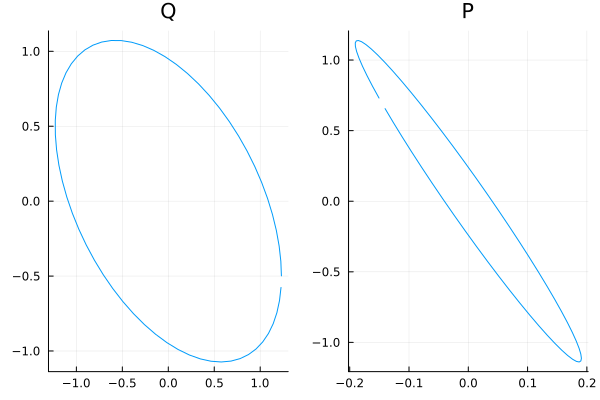

In [4]:
pltQ = plot(1,title="Q",legend=false)
pltP = plot(1,title="P",legend=false)
initVec = []
precision(x) = BigFloat("0.5")^x
for i = 0:0.1:2π
    v = (cos(i)*u1 + sin(i)*u2)
    push!(pltQ,v[1],v[2])
    push!(pltP,v[3],v[4])
    push!(initVec, L4 + v*precision(32))
end
plot(pltQ,pltP)

In [ ]:
plt = plot(1, legend = false)
plt = plot!([L4[1]],[L4[2]],seriestype=:scatter)
param = (mu)
tspan = (0.0,10.0)
for u0 in initVec
    prob = ODEProblem(orbit!,u0,tspan,param)
    sol = solve(prob,Vern9())
    plt = plot!(sol, idxs=(1,2))
end
plot(plt)

In [ ]:
u0 = initVec[1]
tspan = (0.0,10.0)
prob = ODEProblem(orbit!,u0,tspan,param)
sol = solve(prob,Vern9(),dtmax = 0.01)

plot(1,legend=false,title="Q")
pltQ = plot!(sol,idxs=(1,2))
plot(1,legend=false,title="P")
pltP = plot!(sol,idxs=(3,4))
H = []
for u in sol.u
    H = push!(H,hamiltonian((u[3],u[4]),(u[1],u[2]),(mu)))
end
println(H[1])
maxH = maximum(H)
minH = minimum(H)
println(maxH - minH)
pltH = plot(H,legend=false,title="Hamiltonian")

plot(pltQ,pltP,pltH)


In [ ]:
p0 = initVec[1][3:4]
q0 = initVec[1][1:2]
iniV = initVec[1]
tspan = (0.0,10.0)
prob = HamiltonianProblem(hamiltonian,p0,q0,tspan,param)
sol = solve(prob,DPRKN12(),dtmax = 0.1)

plot(1,legend=false,title="Q")
plot!([L4[1]],[L4[2]],seriestype=:scatter)
pltQ = plot!(sol,idxs = (3,4))
plot(1,legend=false,title="P")
plot!([L4[3]],[L4[4]],seriestype=:scatter)
pltP = plot!(sol,idxs=(1,2))
H = []
for u in sol.u
    H = push!(H,hamiltonian((u[1],u[2]),(u[3],u[4]),(mu)))
end
pltH = plot(H,legend=false,title="Hamiltonian")

plot(pltQ,pltP,pltH)
